
# **Лабораторна робота №3**
##### Варіант №8

### **Тема:** Розв’язування систем нелінійних рівнянь

**Мета:** ознайомлення студентів з чисельними методами розв’язування нелінійних
систем; набуття практичних навичок розв’язання таких задач (у тому числі - з
використанням комп’ютера).

Виконали:
1. Михайлюк Віталій
2. Лісовий Максим
3. Андрусик Вікторія
4. Оленич Максим

Лідер команди: **Михайлюк Віталій**

#### **Завдання**

1. Опрацювати теоретичний матеріал
2. Знайти наближений розв’язок заданої нелінійної системи з точністю до
10<sup>-3</sup>

- Методом Ньютона;
- Методом простої ітерації;
- Методом Зейделя.

**Надана система нелінійних рівнянь**

$$
\begin{cases}
\cos(2x - 1) + y = 0,8 \\
x - \cos y = 2
\end{cases}
$$


### **Програмна реалізація**

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Callable, List, Tuple
import math 

In [38]:
def phi(vars: List[float]) -> List[float]:
    x, y = vars
    # Перетворення рівнянь
    # 1) x - cos(y) = 2          =>  x = 2 + cos(y)
    # 2) cos(2x - 1) + y = 0.8   =>  y = 0.8 - cos(2x - 1)
    
    new_x = 2.0 + math.cos(y)
    new_y = 0.8 - math.cos(2.0 * x - 1.0)
    
    return [new_x, new_y]

def phi_1(x: float, y: float) -> float:
    return 2.0 + math.cos(y)

def phi_2(x: float, y: float) -> float:
    return 0.8 - math.cos(2.0 * x - 1.0)

def system_equations(x: np.ndarray) -> np.ndarray:
    return np.array([
        np.cos(2.0 * x[0] - 1.0) + x[1] - 0.8,
        x[0] - np.cos(x[1]) - 2.0
    ])


def system_jacobian(x: np.ndarray) -> np.ndarray:
    return np.array([
        [-2.0 * np.sin(2.0 * x[0] - 1.0), 1.0],
        [1.0, np.sin(x[1])]
    ])

q = 0.85


**Метод Ньютона (Андрусик Вікторія)**

In [39]:
def newton_system(
        func: Callable[[np.ndarray], np.ndarray],
        jacobian: Callable[[np.ndarray], np.ndarray],
        x0: np.ndarray,
        tol: float = 1e-6,
        max_iter: int = 100
) -> Tuple[np.ndarray, int]:
    """
    Метод Ньютона для розв'язання системи нелінійних рівнянь.

    Алгоритм ітеративно знаходить вектор x, для якого F(x) = 0, використовуючи
    формулу x_{k+1} = x_k - J(x_k)^{-1} * F(x_k). Для обчислювальної стабільності
    замість обернення матриці розв'язується СЛАР: J(x_k) * dx = -F(x_k),
    після чого вектор наближень оновлюється: x_{k+1} = x_k + dx.
    """
    x = np.array(x0, dtype=float)

    for i in range(max_iter):
        f_val = func(x)

        # Перевірка умови збіжності за нев'язкою
        if np.linalg.norm(f_val, ord=np.inf) < tol:
            return x, i

        # Обчислення матриці Якобі та приросту dx
        J = jacobian(x)
        dx = np.linalg.solve(J, -f_val)
        x = x + dx

        # Перевірка умови збіжності за приростом аргументу
        if np.linalg.norm(dx, ord=np.inf) < tol:
            return x, i + 1

    raise ValueError("Метод Ньютона не зійшовся за задану кількість ітерацій")

**Метод Зейделя (Лісовий Максим)**

In [40]:
def seidel_nonlinear(
    phi1: Callable[[float, float], float],
    phi2: Callable[[float, float], float],
    x0: float,
    y0: float,
    q: float,
    epsilon: float = 1e-3,
    max_iter: int = 1000
) -> Tuple[float, float, List[float]]:
    """Розв'язує систему нелінійних рівнянь методом Зейделя з критерієм зупинки через q."""
    # Валідація вхідних параметрів
    if not (0.0 < q < 1.0):
        raise ValueError(f"Коефіцієнт стиску q має належати інтервалу (0, 1). Отримано: {q}")
    if epsilon <= 0:
        raise ValueError(f"Точність epsilon має бути додатною. Отримано: {epsilon}")
    if max_iter <= 0:
        raise ValueError(f"Кількість ітерацій max_iter має бути більшою за нуль. Отримано: {max_iter}")

    x_curr, y_curr = float(x0), float(y0)
    errors: List[float] = []

    stop_threshold = epsilon if q <= 0.5 else ((1.0 - q) / q) * epsilon

    for _ in range(max_iter):
        x_prev, y_prev = x_curr, y_curr

        x_curr = phi1(x_prev, y_prev)
        y_curr = phi2(x_curr, y_prev)


        delta = max(abs(x_curr - x_prev), abs(y_curr - y_prev))
        errors.append(delta)

        if delta <= stop_threshold:
            return x_curr, y_curr, errors

    raise RuntimeError(f"Метод Зейделя не зійшовся за {max_iter} ітерацій.")


**Метод простої ітерації (Оленич Максим)**

In [41]:
def simple_iteration_system(
    phi: Callable[[List[float]], List[float]],
    x0: List[float],
    q: float,
    epsilon: float = 0.001,
    max_iter: int = 1000
) -> Tuple[List[float], int]:
    """
    Реалізує метод простої ітерації для розв'язання систем нелінійних рівнянь.
    
    Математична основа:
    Початкова система рівнянь F(x, y) = 0 перетворюється до еквівалентного 
    ітераційного вигляду x = Phi_1(x, y) та y = Phi_2(x, y).
    Процес зупиняється на основі оцінки похибки з використанням 
    коефіцієнта стиску q: ||x_new - x_prev|| <= epsilon * (1 - q) / q.
    
    :param phi: Функція, що реалізує ітераційне відображення Phi(x).
    :param x0: Початкове наближення (список).
    :param q: Коефіцієнт збіжності (константа, q < 1).
    :param epsilon: Задана точність.
    :param max_iter: Максимальна кількість ітерацій.
    :return: Кортеж (список знайдених коренів, кількість витрачених ітерацій).
    """
    
    # Валідація вхідних параметрів
    if epsilon <= 0:
        raise ValueError("Точність epsilon має бути строго більшою за нуль.")
    if max_iter <= 0:
        raise ValueError("Максимальна кількість ітерацій має бути додатнім цілим числом.")
    if not isinstance(x0, list) or len(x0) == 0:
        raise ValueError("Початкове наближення x0 має бути непорожнім списком.")
    if not (0 < q < 1):
        raise ValueError("Коефіцієнт q має бути в межах (0, 1) для гарантії збіжності.")
        
    x_prev = np.array(x0, dtype=float)
    
    for iteration in range(1, max_iter + 1):
        try:
            x_new = np.array(phi(x_prev.tolist()), dtype=float)
        except Exception as e:
            raise RuntimeError(f"Помилка обчислення функції Phi на ітерації {iteration}: {e}")
        
        # Перевірка умови зупинки з використанням q
        max_diff = np.linalg.norm(x_new - x_prev, ord=np.inf)
        
        if max_diff <= epsilon * (1.0 - q) / q:
            return x_new.tolist(), iteration
            
        x_prev = x_new.copy()
        
    raise RuntimeError(f"Метод не зійшовся за {max_iter} ітерацій.")

**Виведення методів**

In [ ]:
if __name__ == "__main__":
    print("-------------------------------------------------------------")
    print("Завдання №1: Метод Ньютона")
    # Пошук першого розв'язку (1, 2)
    try: 
        initial_guess_1 = np.array([1.5, 1.5])
        solution_1, iterations_1 = newton_system(system_equations, system_jacobian, initial_guess_1)
        print(f"Знайдений корінь: {np.round(solution_1, 3)}")
        print(f"Кількість ітерацій: {iterations_1}")
        print(f"Перевірка (F(x) ≈ 0): {system_equations(solution_1)}")
    except Exception as e:
        print("Помилка:", e)
        
    print("-------------------------------------------------------------")
    print("Завдання №2: Метод простої ітерації")
    # Початкове наближення
    # x = 2 + cos(y) -> cos() дає від -1 до 1, тому x в районі 2.
    # y = 0.8 - cos(...) -> y в районі 1.
    initial_guess = [2.0, 1.0] 
    try:
        solution, iters = simple_iteration_system(phi, initial_guess, q=0.85, epsilon=0.001)
        print(f"Знайдений корінь: [{np.round(solution[0], 3)}, {np.round(solution[1], 3)}]")
        print(f"Кількість ітерацій: {iters}")
    except Exception as e:
        print("Помилка:", e)

    print("-------------------------------------------------------------")
    print("Завдання №3: Метод Зейделя")
    try:
        x_sol, y_sol, errors = seidel_nonlinear(phi_1, phi_2, x0=2.0, y0=0.0, q=q, epsilon=1e-3)
        print(f"Знайдений корінь: [{np.round(x_sol, 3)}, {np.round(y_sol, 3)}]")
        print(f"Кількість ітерацій: {len(errors)}")
    except Exception as e:
        print("Помилка:", e)

    print("-------------------------------------------------------------")



-------------------------------------------------------------
Завдання №1: Метод Ньютона
Корінь 1: [1.859 1.712]
Кількість ітерацій: 4
Перевірка (F(x) ≈ 0): [ 1.22820643e-10 -4.28235225e-12]
-------------------------------------------------------------
Завдання №2: Метод простої ітерації
Знайдені корені: x = 1.859, y = 1.712
Кількість ітерацій: 68
-------------------------------------------------------------
Завдання №3: Метод Зейделя
Розв'язок: x* ≈ 1.859, y* ≈ 1.712
Кількість ітерацій: 40
-------------------------------------------------------------


**Візуалізація**

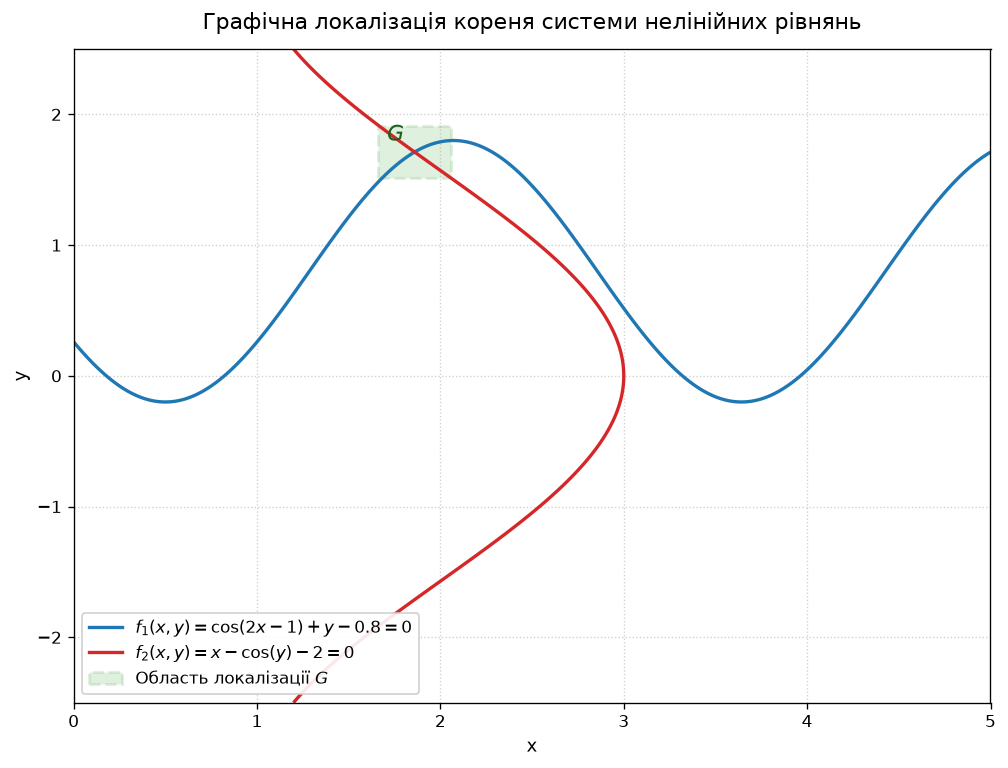

In [43]:
def f1(x, y):
    return np.cos(2.0 * x - 1.0) + y - 0.8

def f2(x, y):
    return x - np.cos(y) - 2.0

x_vals = np.linspace(0, 5, 500)
y_vals = np.linspace(-2.5, 2.5, 500)
X, Y = np.meshgrid(x_vals, y_vals)

Z1 = f1(X, Y)
Z2 = f2(X, Y)

rect_x = [solution_1[0] - 0.2, solution_1[0] + 0.2]
rect_y = [solution_1[1] - 0.2, solution_1[1] + 0.2]

fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=120)

ax.contour(X, Y, Z1, levels=[0], colors='#1f77b4', linewidths=2.0)
ax.contour(X, Y, Z2, levels=[0], colors='#d62728', linewidths=2.0)

ax.plot([], [], color='#1f77b4', lw=2.0, label=r'$f_1(x, y) = \cos(2x - 1) + y - 0.8 = 0$')
ax.plot([], [], color='#d62728', lw=2.0, label=r'$f_2(x, y) = x - \cos(y) - 2 = 0$')

rect = patches.Rectangle(
    (rect_x[0], rect_y[0]), 
    rect_x[1] - rect_x[0],
    rect_y[1] - rect_y[0],
    linewidth=1.8,
    edgecolor='#2ca02c',
    facecolor='#2ca02c',
    alpha=0.15,
    linestyle='--',
    label=r'Область локалізації $G$'
)
ax.add_patch(rect)

ax.text(rect_x[0] + 0.05, rect_y[1] - 0.12, r'$G$', fontsize=13, fontweight='bold', color='#1b611b')

ax.set_title("Графічна локалізація кореня системи нелінійних рівнянь", fontsize=13, pad=12)
ax.set_xlabel("x", fontsize=11)
ax.set_ylabel("y", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='lower left', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.show()

#### **Висновки**

